# QC Exploration — Merck Bioassay Automation Sim
Loads the normalized results from a completed pipeline run and visualises:
1. Plate signal heatmap — spatial view of raw RFU across all 96 wells
2. Percent inhibition histogram — distribution of compound activity
3. Control separation — how well pos/neg controls are separated

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import json

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "sans-serif"

In [2]:
normalized = pd.read_csv("../data/processed/normalized_results_PLT_001.csv")
with open("../data/processed/qc_report_PLT_001.json") as f:
    qc = json.load(f)

print(f"Plate:   {qc['plate_id']}")
print(f"Z'-factor: {qc['z_factor']}")
print(f"S/B ratio: {qc['signal_to_background']}")
print(f"Passed:  {qc['passed']}")
print(f"Wells loaded: {len(normalized)}")

Plate:   PLT_001
Z'-factor: -14.743
S/B ratio: 1.1932
Passed:  False
Wells loaded: 96


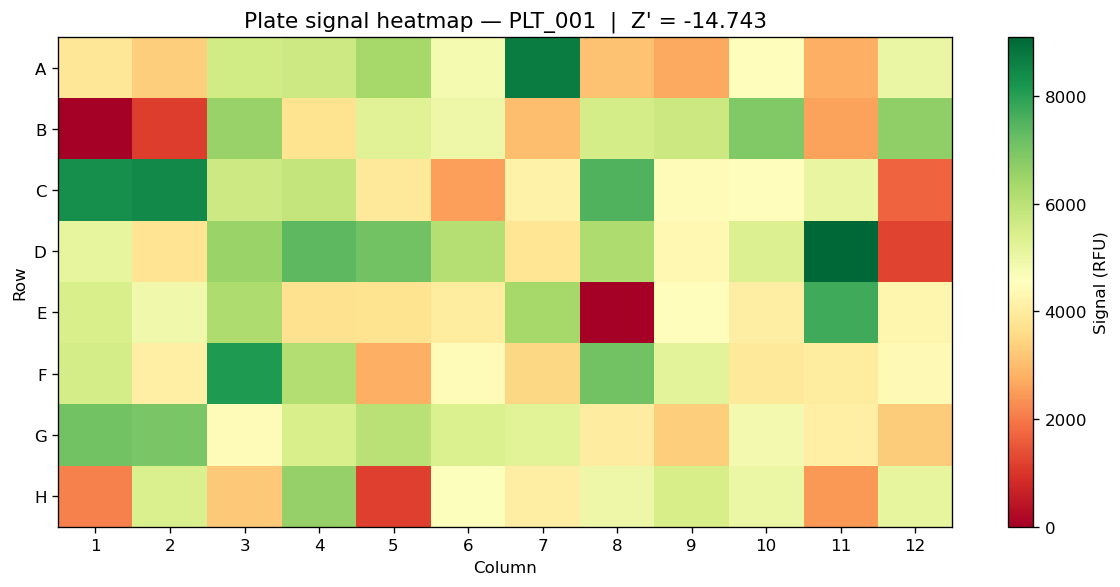

Saved → data/processed/plate_heatmap_PLT_001.png


In [3]:
# Build 8x12 signal matrix from well positions
rows = list("ABCDEFGH")
row_map = {r: i for i, r in enumerate(rows)}

matrix = np.full((8, 12), np.nan)
for _, well in normalized.iterrows():
    r = row_map.get(well["row"])
    c = int(well["column"]) - 1
    if r is not None and 0 <= c < 12:
        matrix[r][c] = well["signal_rfu"]

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(matrix, cmap="RdYlGn", aspect="auto")
plt.colorbar(im, ax=ax, label="Signal (RFU)")

ax.set_xticks(range(12))
ax.set_xticklabels([str(i+1) for i in range(12)])
ax.set_yticks(range(8))
ax.set_yticklabels(list("ABCDEFGH"))
ax.set_title(f"Plate signal heatmap — {qc['plate_id']}  |  Z' = {qc['z_factor']}", 
             fontsize=13)
ax.set_xlabel("Column")
ax.set_ylabel("Row")
plt.tight_layout()
plt.savefig("../data/processed/plate_heatmap_PLT_001.png", dpi=150)
plt.show()
print("Saved → data/processed/plate_heatmap_PLT_001.png")

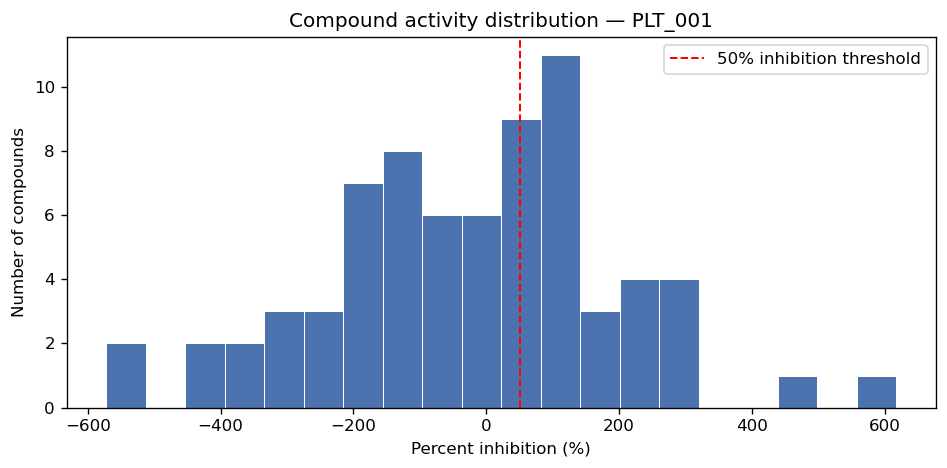

Compounds above 50% inhibition: 26 / 72


In [4]:
compounds = normalized[normalized["well_type"] == "compound"]["percent_inhibition"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(compounds, bins=20, color="#4C72B0", edgecolor="white", linewidth=0.6)
ax.axvline(50, color="red", linestyle="--", linewidth=1.2, label="50% inhibition threshold")
ax.set_xlabel("Percent inhibition (%)")
ax.set_ylabel("Number of compounds")
ax.set_title(f"Compound activity distribution — {qc['plate_id']}")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/inhibition_histogram_PLT_001.png", dpi=150)
plt.show()
print(f"Compounds above 50% inhibition: {(compounds > 50).sum()} / {len(compounds)}")

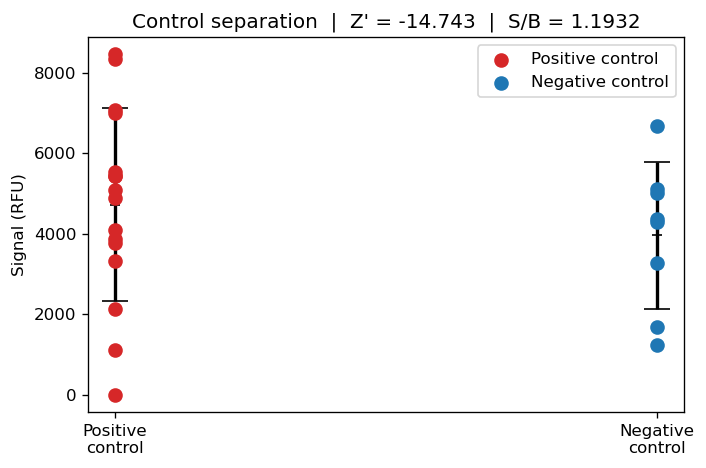

In [5]:
pos = normalized[normalized["well_type"] == "positive_control"]["signal_rfu"]
neg = normalized[normalized["well_type"] == "negative_control"]["signal_rfu"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter([1]*len(pos), pos, color="#d62728", s=60, label="Positive control", zorder=3)
ax.scatter([2]*len(neg), neg, color="#1f77b4", s=60, label="Negative control", zorder=3)
ax.errorbar([1], [pos.mean()], yerr=[pos.std()], fmt="k_", capsize=8, linewidth=2)
ax.errorbar([2], [neg.mean()], yerr=[neg.std()], fmt="k_", capsize=8, linewidth=2)
ax.set_xticks([1, 2])
ax.set_xticklabels(["Positive\ncontrol", "Negative\ncontrol"])
ax.set_ylabel("Signal (RFU)")
ax.set_title(f"Control separation  |  Z' = {qc['z_factor']}  |  S/B = {qc['signal_to_background']}")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/control_separation_PLT_001.png", dpi=150)
plt.show()